<a href="https://colab.research.google.com/github/loicPf/test_ia/blob/main/exercice_qualite_pertinence_TITANIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercice01: Qualité & pertinence des données (Dataset Titanic)
**Version (à compléter)**

## Dataset
On utilise **Titanic** (open-source) via `seaborn.load_dataset("titanic")`.

## Objectif
1) mesurer les **valeurs manquantes**  
2) détecter des **outliers** (méthode IQR) sur `fare`  
3) analyser une **corrélation** avec la cible `survived`  
4) faire un mini **nettoyage** (imputation simple + filtrage + doublons)  
5) vérifier automatiquement avec **Auto-évaluation **

> ⚠️ Exécute les cellules dans l’ordre. Ne modifie pas la cellule d’auto-évaluation.


## 0) Imports + chargement du dataset (avec anomalies ajoutées pour l’exercice)

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
np.random.seed(42)

# Dataset open-source (Seaborn)
df = sns.load_dataset("titanic").copy()

# --- On ajoute volontairement des anomalies pour l’exercice (déterministe) ---
# 1) plus de valeurs manquantes dans age
missing_idx = df.sample(frac=0.05, random_state=42).index
df.loc[missing_idx, "age"] = np.nan

# 2) quelques outliers sur fare (prix très élevés)
out_idx = df.dropna(subset=["fare"]).sample(n=3, random_state=42).index
df.loc[out_idx, "fare"] = df.loc[out_idx, "fare"] * 5

# 3) ajouter 2 doublons exacts
dup_rows = df.sample(n=2, random_state=42)
df = pd.concat([df, dup_rows], ignore_index=True)

df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1) Profil rapide : dimensions + colonnes

In [148]:
# TODO
# créer :
# - n_rows : nombre de lignes
# - n_cols : nombre de colonnes
# - cols   : liste des colonnes

n_rows = df.shape[0]
n_cols = df.columns.size
cols = df.columns.tolist()

print("n_rows =", n_rows)
print("n_cols =", n_cols)
print("cols =", cols)


n_rows = 893
n_cols = 15
cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


## 2) Complétude : valeurs manquantes (table + focus sur `age`)

In [149]:
# TODO
# 1) créer un DataFrame missing_table avec :
#    - missing_count (nb de NaN)
#    - missing_pct   (% de NaN)
# 2) créer missing_pct_age (% de NaN dans age)

missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
missing_pct_age = missing_table.loc["age", "missing_pct"]

display(missing_table.head(10) if missing_table is not None else None)
print("missing_pct_age =", missing_pct_age)


,missing_count,missing_pct
survived,0,0.00
pclass,0,0.00
sex,0,0.00
age,213,23.85
sibsp,0,0.00
parch,0,0.00
fare,0,0.00
embarked,2,0.22
class,0,0.00
who,0,0.00


missing_pct_age = 23.85


## 3) Doublons exacts

In [150]:
# TODO
# créer n_duplicates : nb de lignes dupliquées (exactes)
n_duplicates = df.duplicated().sum()
print("n_duplicates =", n_duplicates)


n_duplicates = 115


## 4) Outliers : méthode IQR sur `fare`

In [151]:
# TODO
# 1) calculer q1, q3, iqr sur fare (ignore NaN)
# 2) lower = Q1 - 1.5*IQR ; upper = Q3 + 1.5*IQR
# 3) n_outliers_fare = nb de valeurs hors [lower, upper]
f = df["fare"].dropna()
q1 = f.quantile(0.25)
q3 = f.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
n_outliers_fare = ((f < lower) | (f > upper)).sum()

print("Q1 =", q1, "| Q3 =", q3, "| IQR =", iqr)
print("lower =", lower, "| upper =", upper)
print("n_outliers_fare =", n_outliers_fare)


Q1 = 7.925 | Q3 = 31.275 | IQR = 23.349999999999998
lower = -27.099999999999998 | upper = 66.3
n_outliers_fare = 118


## 5) Signal rapide : corrélation avec la cible `survived` (numériques)

In [152]:
# TODO
# 1) calculer corr_survived_fare (corrélation survived vs fare)
# 2) trouver top_feature : variable numérique (hors survived) la plus corrélée à survived en valeur absolue

corr_survived_fare = df["survived"].corr(df["fare"])
top_feature = df.select_dtypes(include=[np.number]).drop("survived", axis=1).corrwith(df["survived"]).index[0]

print("corr_survived_fare =", corr_survived_fare)
print("top_feature =", top_feature)


corr_survived_fare = 0.2581139862193536
top_feature = pclass


## 6) Pertinence simple : taux de survie par `sex`

In [153]:
# TODO
# créer survival_rate_by_sex : moyenne de survived par sex (triée décroissant)
survival_rate_by_sex = df.groupby("sex")["survived"].mean().sort_values(ascending=False)

display(survival_rate_by_sex)


,survived
sex,
female,0.742038
male,0.189983


## 7) Visualisation rapide (2 graphiques) : `fare`

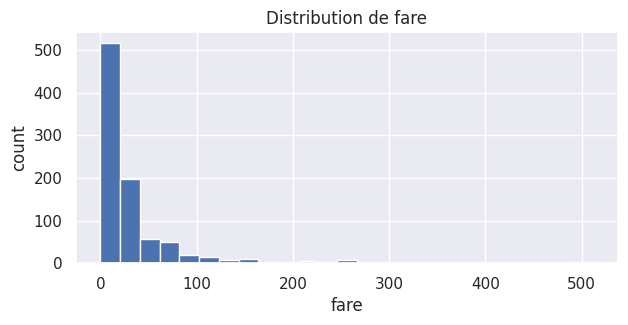

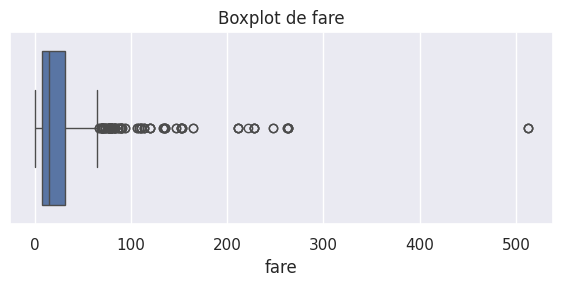

In [154]:
plt.figure(figsize=(7,3))
plt.hist(df["fare"].dropna(), bins=25)
plt.title("Distribution de fare")
plt.xlabel("fare")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(7,2.5))
sns.boxplot(x=df["fare"])
plt.title("Boxplot de fare")
plt.xlabel("fare")
plt.show()


## 8) Mini nettoyage (simple)

In [159]:
# TODO
# Construire df_clean :
# 1) enlever les doublons exacts
# 2) imputer age par la médiane (sur df_clean)
# 3) filtrer fare dans [lower, upper]
# Puis stocker df_clean_shape (tuple) et age_median

df_clean = df.drop_duplicates().copy()
age_median = float(df_clean["age"].median())
df_clean_shape = df_clean[df_clean["fare"].between(lower, upper)].shape

print("age_median =", age_median)
print("df_clean_shape =", df_clean_shape)


age_median = 29.0
df_clean_shape = (667, 15)


## 9) Conclusion (1–2 phrases)

In [160]:
# TODO
# Écris une conclusion courte dans 'conclusion' (1 à 2 phrases)
conclusion = "Il vaut mieux etre une femme riche et jeune"

print(conclusion)


Il vaut mieux etre une femme riche et jeune


## 10) Auto-évaluation (ne pas modifier)

In [161]:
# Auto-évaluation (ne pas modifier)
import numpy as np
import pandas as pd
import seaborn as sns

def _fail(msg):
    raise AssertionError(msg)

required = [
    "n_rows", "n_cols", "cols",
    "missing_table", "missing_pct_age",
    "n_duplicates",
    "q1", "q3", "iqr", "lower", "upper", "n_outliers_fare",
    "corr_survived_fare", "top_feature",
    "survival_rate_by_sex",
    "df_clean", "age_median", "df_clean_shape",
    "conclusion"
]
for v in required:
    if v not in globals():
        _fail(f"Variable manquante: {v}")

# Recompute expected deterministically (same steps as notebook)
np.random.seed(42)
df_ref = sns.load_dataset("titanic").copy()

missing_idx = df_ref.sample(frac=0.05, random_state=42).index
df_ref.loc[missing_idx, "age"] = np.nan

out_idx = df_ref.dropna(subset=["fare"]).sample(n=3, random_state=42).index
df_ref.loc[out_idx, "fare"] = df_ref.loc[out_idx, "fare"] * 5

dup_rows = df_ref.sample(n=2, random_state=42)
df_ref = pd.concat([df_ref, dup_rows], ignore_index=True)

# Expected basics
exp_n_rows, exp_n_cols = df_ref.shape
exp_cols = df_ref.columns.tolist()

# Expected missing
missing_count = df_ref.isna().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df_ref) * 100).round(2)
exp_missing_table = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
exp_missing_pct_age = float(exp_missing_table.loc["age", "missing_pct"])

# Expected duplicates
exp_n_duplicates = int(df_ref.duplicated().sum())

# Expected IQR on fare
f = df_ref["fare"].dropna()
exp_q1 = f.quantile(0.25)
exp_q3 = f.quantile(0.75)
exp_iqr = exp_q3 - exp_q1
exp_lower = exp_q1 - 1.5 * exp_iqr
exp_upper = exp_q3 + 1.5 * exp_iqr
exp_n_outliers = int(((f < exp_lower) | (f > exp_upper)).sum())

# Expected correlations
num_df = df_ref.select_dtypes(include=[np.number])
corr = num_df.corr(numeric_only=True)
exp_corr_survived_fare = float(corr.loc["survived", "fare"])
s = corr["survived"].drop("survived")
exp_top_feature = str(s.abs().sort_values(ascending=False).index[0])

# Expected groupby
exp_survival_rate_by_sex = df_ref.groupby("sex")["survived"].mean().sort_values(ascending=False).round(3)

# Expected cleaning
df_clean_ref = df_ref.drop_duplicates().copy()
exp_age_median = float(df_clean_ref["age"].median())
df_clean_ref["age"] = df_clean_ref["age"].fillna(exp_age_median)
df_clean_ref = df_clean_ref[df_clean_ref["fare"].between(exp_lower, exp_upper)].copy()
exp_clean_shape = df_clean_ref.shape

# Assertions
if n_rows != exp_n_rows or n_cols != exp_n_cols:
    _fail("Q1 incorrect : vérifie n_rows / n_cols.")
if cols != exp_cols:
    _fail("Q1 incorrect : vérifie la liste cols.")

try:
    if float(missing_table.loc["age", "missing_pct"]) != exp_missing_pct_age:
        _fail("Q2 incorrect : missing_table / age missing_pct.")
except Exception:
    _fail("Q2 incorrect : missing_table format ou index.")

print(float(missing_pct_age) - exp_missing_pct_age)
if abs(float(missing_pct_age) - exp_missing_pct_age) > 1e-6:
    _fail("Q2 incorrect : missing_pct_age.")

if int(n_duplicates) != exp_n_duplicates:
    _fail("Q3 incorrect : n_duplicates.")

for name, val, exp in [
    ("q1", q1, exp_q1), ("q3", q3, exp_q3), ("iqr", iqr, exp_iqr),
    ("lower", lower, exp_lower), ("upper", upper, exp_upper)
]:
    if not np.isfinite(float(val)):
        _fail(f"Q4 incorrect : {name} non numérique.")
    if abs(float(val) - float(exp)) > 1e-6:
        _fail(f"Q4 incorrect : {name}.")

if int(n_outliers_fare) != exp_n_outliers:
    _fail("Q4 incorrect : n_outliers_fare.")

if abs(float(corr_survived_fare) - exp_corr_survived_fare) > 1e-6:
    _fail("Q5 incorrect : corr_survived_fare.")
if str(top_feature) != exp_top_feature:
    _fail("Q5 incorrect : top_feature.")

# compare groupby series
try:
    if not exp_survival_rate_by_sex.equals(survival_rate_by_sex.round(3)):
        _fail("Q6 incorrect : survival_rate_by_sex.")
except Exception:
    _fail("Q6 incorrect : survival_rate_by_sex format.")

if df_clean_shape != exp_clean_shape:
    _fail("Q8 incorrect : df_clean_shape.")

if abs(float(age_median) - exp_age_median) > 1e-6:
    _fail("Q8 incorrect : age_median.")

if not isinstance(conclusion, str) or len(conclusion.strip()) < 20:
    _fail("Q9 : conclusion trop courte (au moins ~1 phrase).")

print("✅ OK — Tout est correct. Bravo !")


0.0
✅ OK — Tout est correct. Bravo !
